### **Augmentation :-**

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os
import PIL
import cv2

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import  Sequential


### **Load flower dataset: -**

In [19]:
data_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos',origin = data_url ,cache_dir='.',untar = True)
# cache_dir indicates where to download data. I specified . which means current directory
# untar true will unzip it

In [20]:
data_dir

'./datasets/flower_photos'

In [21]:
import pathlib
from pathlib import Path

data_dir = pathlib.Path(data_dir)
data_dir

PosixPath('datasets/flower_photos')

In [22]:
print(data_dir.exists())  # Should be True
print(list(data_dir.glob('*')))
print(list(data_dir.glob('*//*.jpg')))

True
[PosixPath('datasets/flower_photos/flower_photos')]
[]


In [23]:
data_dir = Path("datasets/flower_photos/flower_photos")

In [24]:
list(data_dir.glob('*/*.jpg'))[:5]

[PosixPath('datasets/flower_photos/flower_photos/roses/16209331331_343c899d38.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/5777669976_a205f61e5b.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/4860145119_b1c3cbaa4e_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/15011625580_7974c44bce.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/17953368844_be3d18cf30_m.jpg')]

In [25]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)

3670


In [26]:
roses = list(data_dir.glob('roses/*'))
roses[:5]

[PosixPath('datasets/flower_photos/flower_photos/roses/16209331331_343c899d38.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/5777669976_a205f61e5b.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/4860145119_b1c3cbaa4e_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/15011625580_7974c44bce.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/17953368844_be3d18cf30_m.jpg')]

In [28]:
roses[1]

PosixPath('datasets/flower_photos/flower_photos/roses/5777669976_a205f61e5b.jpg')

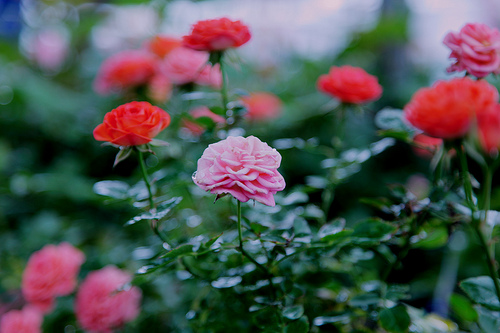

In [27]:
PIL.Image.open(str(roses[1]))

In [29]:
tulips = list(data_dir.glob('tulips/*'))
tulips[8]

PosixPath('datasets/flower_photos/flower_photos/tulips/5543457754_89c44c88de_n.jpg')

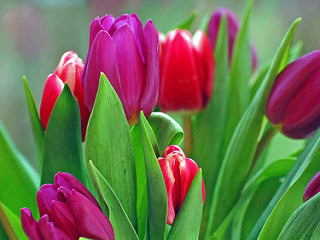

In [33]:
PIL.Image.open(str(tulips[104]))

In [34]:
flowers_image_dict = {
    'roses' : list(data_dir.glob('roses/*')),
    'daisy' : list(data_dir.glob('daisy/*')),
    'dandelion' : list(data_dir.glob('dandelion/*')),
    'sunflowers' : list(data_dir.glob('sunflowers/*')),
    'tulips' : list(data_dir.glob('tulips/*')),
}

In [35]:
flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

In [36]:
flowers_image_dict['roses'][:5]

[PosixPath('datasets/flower_photos/flower_photos/roses/16209331331_343c899d38.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/5777669976_a205f61e5b.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/4860145119_b1c3cbaa4e_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/15011625580_7974c44bce.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/17953368844_be3d18cf30_m.jpg')]

In [ ]:
str(flowers_image_dict['roses'][:5])

"[PosixPath('datasets/flower_photos/flower_photos/roses/16209331331_343c899d38.jpg'), PosixPath('datasets/flower_photos/flower_photos/roses/5777669976_a205f61e5b.jpg'), PosixPath('datasets/flower_photos/flower_photos/roses/4860145119_b1c3cbaa4e_n.jpg'), PosixPath('datasets/flower_photos/flower_photos/roses/15011625580_7974c44bce.jpg'), PosixPath('datasets/flower_photos/flower_photos/roses/17953368844_be3d18cf30_m.jpg')]"

### **Convert Image into matrix.**

In [42]:
img = cv2.imread(str(flowers_image_dict['roses'][9]))
img.shape

(334, 500, 3)

In [40]:
cv2.resize(img,(180,180)).shape

(180, 180, 3)

In [43]:
x = []
y = []
for flower_name ,images in flowers_image_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img,(180,180))
        x.append(resized_img)
        y.append(flowers_labels_dict[flower_name])


x = np.array(x)
y = np.array(y) 

In [44]:
x

array([[[[  2,   0,   2],
         [ 10,   5,   1],
         [ 89,  85,  97],
         ...,
         [244, 245, 243],
         [244, 245, 243],
         [244, 245, 243]],

        [[ 14,  33,  73],
         [  6,   1,   2],
         [ 92,  90, 105],
         ...,
         [243, 244, 242],
         [244, 245, 243],
         [243, 244, 242]],

        [[122, 176, 224],
         [ 10,   1,   2],
         [ 72,  80,  84],
         ...,
         [244, 245, 243],
         [244, 245, 243],
         [244, 245, 243]],

        ...,

        [[147, 109,  85],
         [145, 109,  85],
         [144, 108,  84],
         ...,
         [155, 122,  96],
         [152, 121,  95],
         [149, 118,  93]],

        [[148, 114,  91],
         [154, 120,  96],
         [146, 112,  88],
         ...,
         [155, 125,  98],
         [153, 121,  95],
         [152, 122,  93]],

        [[153, 119,  96],
         [151, 117,  93],
         [152, 117,  94],
         ...,
         [154, 124,  97],
        

### **Spliting the data: -**

In [45]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train, y_test = train_test_split(x,y,random_state = 4)


### **Scaling data:**

In [46]:
X_train_scaled = x_train / 255
X_test_scaled = x_test / 255

### **Buid a Convolutional Neural Networks: -**

In [49]:
num_classes = 5

model = Sequential([
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes,activation = 'softmax')
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
              
model.fit(X_train_scaled, y_train, epochs=10) 

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 14s 155ms/step - accuracy: 0.3066 - loss: 1.6061
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 13s 150ms/step - accuracy: 0.5861 - loss: 1.0562
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 13s 150ms/step - accuracy: 0.6988 - loss: 0.7994
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 14s 165ms/step - accuracy: 0.7844 - loss: 0.6001
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 14s 167ms/step - accuracy: 0.8678 - loss: 0.4047
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 171ms/step - accuracy: 0.9234 - loss: 0.2326
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 171ms/step - accuracy: 0.9490 - loss: 0.1606
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 174ms/step - accuracy: 0.9830 - loss: 0.0817
Epoch 9/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 175ms/step - accuracy: 0.9901 - loss: 0.0496
Epoch 10/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 175ms/step - accuracy: 0.9917 - loss: 0.0374


In [50]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.6211 - loss: 2.3537


[2.361482620239258, 0.6220043301582336]

### **Improving accuracy using agumentation: -**

In [66]:
from tensorflow import keras
from tensorflow.keras import layers

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal", input_shape=(180, 180, 3)),
    layers.RandomFlip("vertical", input_shape=(180, 180, 3)),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2)
])


/Users/yuvrajbhatkariya/data/VScode.C++/Python/myenv/lib/python3.12/site-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


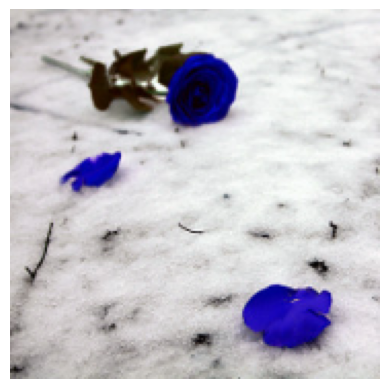

In [67]:
plt.axis('off')
plt.imshow(x[6])

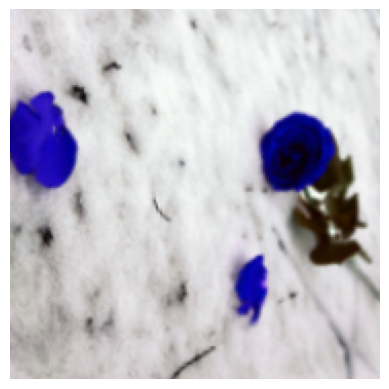

In [68]:
plt.axis('off')
plt.imshow(data_augmentation(x)[6].numpy().astype("uint8"))

In [74]:
num_classes = 5

model = Sequential([
  data_augmentation,
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.3),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(64, activation='relu'),
  layers.Dense(32, activation='relu'),
  # layers.Dropout(0.2),
  layers.Dense(num_classes,activation = 'softmax')
])
# model.summary()
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
              
model.fit(X_train_scaled, y_train, epochs=15) 

Epoch 1/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 16s 177ms/step - accuracy: 0.3284 - loss: 1.4774
Epoch 2/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 18s 207ms/step - accuracy: 0.5511 - loss: 1.0594
Epoch 3/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 16s 188ms/step - accuracy: 0.5945 - loss: 1.0112
Epoch 4/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 18s 206ms/step - accuracy: 0.6278 - loss: 0.9243
Epoch 5/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 18s 214ms/step - accuracy: 0.6312 - loss: 0.9009
Epoch 6/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 20s 232ms/step - accuracy: 0.6656 - loss: 0.8633
Epoch 7/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 20s 234ms/step - accuracy: 0.6636 - loss: 0.8472
Epoch 8/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 20s 237ms/step - accuracy: 0.6876 - loss: 0.7813
Epoch 9/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 19s 225ms/step - accuracy: 0.6824 - loss: 0.7904
Epoch 10/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 17s 202ms/step - accuracy: 0.7222 - loss: 0.7122
Epoch 11/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 17s 199ms/step - accuracy: 0.7192 - loss: 0.7180
Epoch 12/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 17

In [73]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.6502 - loss: 0.9972


[0.9346778392791748, 0.6699346303939819]